In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
saicharan2003_mnist_path = kagglehub.notebook_output_download('saicharan2003/mnist')
hossamahmedsalah_fashion_mnist_path = kagglehub.notebook_output_download('hossamahmedsalah/fashion-mnist')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mnist/__results__.html
/kaggle/input/mnist/__notebook_source__.ipynb
/kaggle/input/mnist/__resultx__.html
/kaggle/input/mnist/__notebook__.ipynb
/kaggle/input/mnist/__output__.json
/kaggle/input/mnist/predictions.csv
/kaggle/input/mnist/custom.css
/kaggle/input/mnist/__results___files/__results___2_1.png
/kaggle/input/fashion-mnist/__results__.html
/kaggle/input/fashion-mnist/__notebook__.ipynb
/kaggle/input/fashion-mnist/__output__.json
/kaggle/input/fashion-mnist/custom.css
/kaggle/input/fashion-mnist/__results___files/__results___13_3.png
/kaggle/input/fashion-mnist/__results___files/__results___13_9.png
/kaggle/input/fashion-mnist/__results___files/__results___130_1.png
/kaggle/input/fashion-mnist/__results___files/__results___118_1.png
/kaggle/input/fashion-mnist/__results___files/__results___13_7.png
/kaggle/input/fashion-mnist/__results___files/__results___13_5.png
/kaggle/input/fashion-mnist/__results___files/__results___91_0.png
/kaggle/input/fashion-mnist/__resu

In [ ]:
!pip install ptflops tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, resnet50
from torch.utils.data import DataLoader, random_split, Subset
from sklearn.metrics import accuracy_score
import time
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from ptflops import get_model_complexity_info

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(3),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

full = torchvision.datasets.FashionMNIST("./data", train=True, transform=transform, download=True)
test = torchvision.datasets.FashionMNIST("./data", train=False, transform=transform, download=True)

total = len(full)
train_size = int(0.7*total)
val_size = int(0.1*total)
test_size = total - train_size - val_size

fmnist_train, fmnist_val, _ = random_split(full, [train_size, val_size, test_size])

# Use subset for faster demo (still valid for comparison)
fmnist_train = Subset(fmnist_train, range(5000))
fmnist_test  = Subset(test, range(2000))


In [ ]:
batch_size = 16
train_loader = DataLoader(fmnist_train, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(fmnist_test, batch_size=batch_size)


In [ ]:
def get_model(name):
    if name == "resnet18":
        model = resnet18(weights=None)
    else:
        model = resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model


In [ ]:
scaler = torch.amp.GradScaler("cuda")

def train_model(model, loader, optimizer, epochs, device):
    model.train()
    criterion = nn.CrossEntropyLoss()
    start = time.time()

    for ep in range(epochs):
        loop = tqdm(loader, desc=f"Epoch {ep+1}/{epochs}")
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast("cuda" if device.type=="cuda" else "cpu"):
                loss = criterion(model(x), y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            loop.set_postfix(loss=loss.item())

    return (time.time() - start)*1000


In [ ]:
def evaluate(model, loader, device):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds.extend(model(x).argmax(1).cpu().numpy())
            labels.extend(y.cpu().numpy())

    return accuracy_score(labels, preds)*100


In [ ]:
def get_flops(model):
    flops, params = get_model_complexity_info(model, (3,224,224), as_strings=False)
    return flops


##### q2_results = []

for compute in ["cpu","cuda"]:
    device = torch.device(compute)

    for model_name in ["resnet18","resnet50"]:
        print(f"\nRunning {model_name} on {compute}")

        model = get_model(model_name).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        train_time = train_model(model, train_loader, optimizer, epochs=1)
        acc = evaluate(model, test_loader)
        flops = get_flops(model)

        q2_results.append([compute, model_name, acc, train_time, flops])


In [ ]:
q2_results = []

for compute in ["cpu","cuda"]:
    if compute=="cuda" and not torch.cuda.is_available():
        continue

    device = torch.device(compute)

    for opt_name in ["SGD","Adam"]:
        for model_name in ["resnet18","resnet50"]:
            print(f"\n{model_name} | {compute} | {opt_name}")

            model = get_model(model_name).to(device)
            optimizer = optim.SGD(model.parameters(), lr=0.001) if opt_name=="SGD" else optim.Adam(model.parameters(), lr=0.001)

            train_time = train_model(model, train_loader, optimizer, epochs=1, device=device)
            acc = evaluate(model, test_loader, device)
            flops = get_flops(model)

            q2_results.append([compute, opt_name, model_name, acc, train_time, flops])



resnet18 | cpu | SGD


Epoch 1/1: 100%|██████████| 313/313 [15:51<00:00,  3.04s/it, loss=1.78]


ResNet(
  11.18 M, 100.000% Params, 1.82 GMac, 99.828% MACs, 
  (conv1): Conv2d(9.41 k, 0.084% Params, 118.01 MMac, 6.467% MACs, 3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(128, 0.001% Params, 1.61 MMac, 0.088% MACs, 64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(0, 0.000% Params, 802.82 KMac, 0.044% MACs, inplace=True)
  (maxpool): MaxPool2d(0, 0.000% Params, 802.82 KMac, 0.044% MACs, kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    147.97 k, 1.323% Params, 464.83 MMac, 25.473% MACs, 
    (0): BasicBlock(
      73.98 k, 0.662% Params, 232.42 MMac, 12.736% MACs, 
      (conv1): Conv2d(36.86 k, 0.330% Params, 115.61 MMac, 6.335% MACs, 64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, 0.001% Params, 401.41 KMac, 0.022% MACs, 64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(0,

Epoch 1/1: 100%|██████████| 313/313 [40:24<00:00,  7.75s/it, loss=1.78]


ResNet(
  23.53 M, 100.000% Params, 4.12 GMac, 99.746% MACs, 
  (conv1): Conv2d(9.41 k, 0.040% Params, 118.01 MMac, 2.857% MACs, 3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(128, 0.001% Params, 1.61 MMac, 0.039% MACs, 64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(0, 0.000% Params, 802.82 KMac, 0.019% MACs, inplace=True)
  (maxpool): MaxPool2d(0, 0.000% Params, 802.82 KMac, 0.019% MACs, kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    215.81 k, 0.917% Params, 680.39 MMac, 16.473% MACs, 
    (0): Bottleneck(
      75.01 k, 0.319% Params, 236.43 MMac, 5.724% MACs, 
      (conv1): Conv2d(4.1 k, 0.017% Params, 12.85 MMac, 0.311% MACs, 64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, 0.001% Params, 401.41 KMac, 0.010% MACs, 64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(36.86 k, 0.157% Par

...

ResNet(
  23.53 M, 100.000% Params, 4.12 GMac, 99.746% MACs, 
  (conv1): Conv2d(9.41 k, 0.040% Params, 118.01 MMac, 2.857% MACs, 3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(128, 0.001% Params, 1.61 MMac, 0.039% MACs, 64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(0, 0.000% Params, 802.82 KMac, 0.019% MACs, inplace=True)
  (maxpool): MaxPool2d(0, 0.000% Params, 802.82 KMac, 0.019% MACs, kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    215.81 k, 0.917% Params, 680.39 MMac, 16.473% MACs, 
    (0): Bottleneck(
      75.01 k, 0.319% Params, 236.43 MMac, 5.724% MACs, 
      (conv1): Conv2d(4.1 k, 0.017% Params, 12.85 MMac, 0.311% MACs, 64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, 0.001% Params, 401.41 KMac, 0.010% MACs, 64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(36.86 k, 0.157% Par

Epoch 1/1: 100%|██████████| 313/313 [00:15<00:00, 19.83it/s, loss=1.1]  


ResNet(
  11.18 M, 100.000% Params, 1.82 GMac, 99.828% MACs, 
  (conv1): Conv2d(9.41 k, 0.084% Params, 118.01 MMac, 6.467% MACs, 3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(128, 0.001% Params, 1.61 MMac, 0.088% MACs, 64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(0, 0.000% Params, 802.82 KMac, 0.044% MACs, inplace=True)
  (maxpool): MaxPool2d(0, 0.000% Params, 802.82 KMac, 0.044% MACs, kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    147.97 k, 1.323% Params, 464.83 MMac, 25.473% MACs, 
    (0): BasicBlock(
      73.98 k, 0.662% Params, 232.42 MMac, 12.736% MACs, 
      (conv1): Conv2d(36.86 k, 0.330% Params, 115.61 MMac, 6.335% MACs, 64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, 0.001% Params, 401.41 KMac, 0.022% MACs, 64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(0,

Epoch 1/1: 100%|██████████| 313/313 [00:33<00:00,  9.48it/s, loss=0.434]


ResNet(
  23.53 M, 100.000% Params, 4.12 GMac, 99.746% MACs, 
  (conv1): Conv2d(9.41 k, 0.040% Params, 118.01 MMac, 2.857% MACs, 3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(128, 0.001% Params, 1.61 MMac, 0.039% MACs, 64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(0, 0.000% Params, 802.82 KMac, 0.019% MACs, inplace=True)
  (maxpool): MaxPool2d(0, 0.000% Params, 802.82 KMac, 0.019% MACs, kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    215.81 k, 0.917% Params, 680.39 MMac, 16.473% MACs, 
    (0): Bottleneck(
      75.01 k, 0.319% Params, 236.43 MMac, 5.724% MACs, 
      (conv1): Conv2d(4.1 k, 0.017% Params, 12.85 MMac, 0.311% MACs, 64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, 0.001% Params, 401.41 KMac, 0.010% MACs, 64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(36.86 k, 0.157% Par

In [ ]:
q2_df = pd.DataFrame(q2_results, columns=[
    "Compute","Optimizer","Model","Accuracy (%)","Train Time (ms)","FLOPs"
])

q2_df


,Compute,Optimizer,Model,Accuracy (%),Train Time (ms),FLOPs
0,cpu,SGD,resnet18,46.25,9.511200e+05,1824805898
1,cpu,SGD,resnet50,23.05,2.424643e+06,4130408458
2,cpu,Adam,resnet18,75.60,9.891068e+05,1824805898
3,cpu,Adam,resnet50,70.35,2.355874e+06,4130408458
4,cuda,SGD,resnet18,35.55,1.711225e+04,1824805898
5,cuda,SGD,resnet50,17.80,3.268896e+04,4130408458
6,cuda,Adam,resnet18,72.45,1.578898e+04,1824805898
7,cuda,Adam,resnet50,65.70,3.300805e+04,4130408458


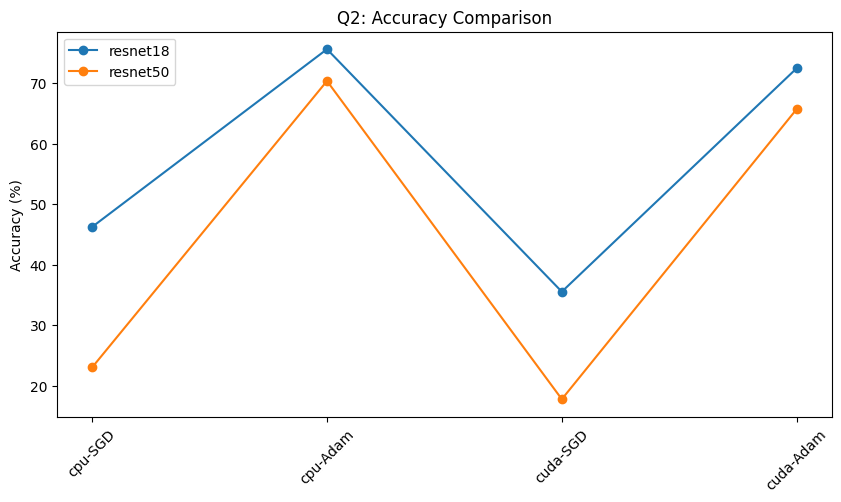

In [ ]:
plt.figure(figsize=(10,5))
for model in ["resnet18","resnet50"]:
    subset = q2_df[q2_df.Model==model]
    plt.plot(subset.Compute + "-" + subset.Optimizer, subset["Accuracy (%)"], marker='o', label=model)

plt.title("Q2: Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.legend()
plt.show()


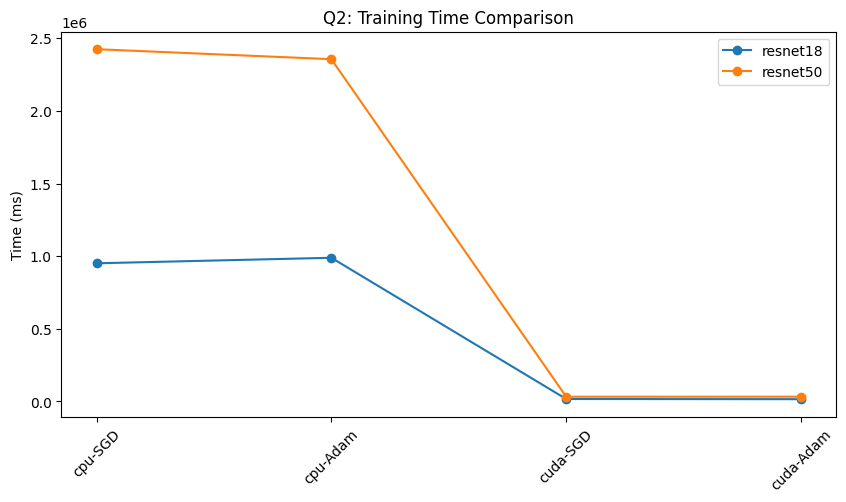

In [ ]:
plt.figure(figsize=(10,5))
for model in ["resnet18","resnet50"]:
    subset = q2_df[q2_df.Model==model]
    plt.plot(subset.Compute + "-" + subset.Optimizer, subset["Train Time (ms)"], marker='o', label=model)

plt.title("Q2: Training Time Comparison")
plt.ylabel("Time (ms)")
plt.xticks(rotation=45)
plt.legend()
plt.show()
